# OT in linar ICA

#### In this notebook, we genrate mixtures by randomly picking distributions, whether discrete or continous. We also keep at most one gaussian to confirm tractability of ICA with one gaussian. We compare how Fast ICA and OT ICA perform on 10 to 75 dima with 5 dim leap and 10,000 samples wiht max of 150 starts in phase 1 SGD step and phase 2 incorporating Stiefel manifold.

In [1]:
import numpy as np
import torch
import pandas as pd
import time
from sklearn.decomposition import FastICA
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from wasserstein_ica import WassersteinICA

In [2]:
def amari_error(W, A):
    """
    Computes the Amari Error to evaluate the performance of ICA.
    An error close to 0 indicates perfect separation.
    
    W: Estimated unmixing matrix (n_components, n_features)
    A: True mixing matrix (n_features, n_sources)
    """
    # P is the global matrix representing the combined effect of mixing and unmixing
    P = np.dot(W, A)
    P_abs = np.abs(P)
    
    # 1. Sum of row-wise errors
    row_max = np.max(P_abs, axis=1, keepdims=True)
    row_term = np.sum(P_abs / row_max, axis=1) - 1.0
    
    # 2. Sum of column-wise errors
    col_max = np.max(P_abs, axis=0, keepdims=True)
    col_term = np.sum(P_abs / col_max, axis=0) - 1.0
    
    # Average over the number of components
    n = P.shape[0]
    return (np.sum(row_term) + np.sum(col_term)) / (2 * n)

In [3]:
# ==========================================
# 1. The Generalized Hybrid Mixture Generator
# ==========================================

def generate_general_mixture(n_dim, n_samples, seed=None):
    """
    Generates a generalized ICA dataset.
    Ensures exactly ONE source is Gaussian.
    Randomly pulls the remaining (n_dim - 1) sources from a diverse pool 
    of discrete and continuous non-Gaussian distributions.
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    sources = []
    
    # 1. Inject Exactly ONE Gaussian Source
    sources.append(np.random.normal(0, 1, size=n_samples))
    
    # 2. Define the Non-Gaussian Pool (all naturally or explicitly standardized)
    def gen_laplace(): 
        return np.random.laplace(0, 1 / np.sqrt(2), size=n_samples)
    def gen_bernoulli(): 
        return np.random.choice([-1.0, 1.0], size=n_samples)
    def gen_uniform(): 
        return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    def gen_student_t(): 
        s = np.random.standard_t(df=3, size=n_samples)
        return s / np.std(s) # Standardize due to heavy tails
    def gen_poisson():
        s = np.random.poisson(lam=3, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
    def gen_binomial():
        s = np.random.binomial(n=10, p=0.5, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
    def gen_chisquare():
        s = np.random.chisquare(df=2, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
    def gen_exponential():
        s = np.random.exponential(scale=1.0, size=n_samples)
        return (s - np.mean(s)) / np.std(s) # Center and scale
        
    pool = [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, 
            gen_poisson, gen_binomial, gen_chisquare, gen_exponential]
            
    # 3. Generate the remaining (n_dim - 1) sources
    for _ in range(n_dim - 1):
        # Select a random distribution generator from the pool
        generator = np.random.choice(pool)
        sources.append(generator())
        
    S = np.stack(sources)
    
    # Shuffle the rows so the Gaussian source is at a random index
    np.random.shuffle(S)
    
    # 4. Generate a well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [4]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================

def run_general_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_torch, A_true = generate_general_mixture(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
    
    # --- W-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        
        # 1. Deflationary Phase (Applying mild dithering to handle the discrete sources)
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=200, 
                n_restarts=n_restarts, 
                dither_sigma=0.01
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 2. Symmetric Stiefel Phase 
        # (Using stochastic batching and dithering due to complex hybrid landscape)
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=400,        # Longer settling time for complex landscape
            lr=0.25,             # Lower learning rate for stability
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   # Smoothing for discrete variables
            batch_size=1024      # Stochastic bouncing to escape local maxima
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'W-ICA (Stiefel)', 'Amari Error': score_wass})
    
    return trial_results

In [5]:
# ==========================================
# 3. Main Execution & Plotting
# ==========================================
DIMENSIONS = list(range(10, 80, 5)) # [10, 15, 20, ..., 75]
N_SAMPLES = 10000 
N_TRIALS = 5

print(f"--- FastICA vs W-ICA: Generalized Hybrid Mixture ---")
print(f"Testing Dimensions: {DIMENSIONS}")

tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]
results_nested = []

# Using n_jobs=4 to prevent PyTorch CUDA locks as tuned previously
with Parallel(n_jobs=4, return_as="generator") as parallel:
    jobs = (delayed(run_general_trial)(dim, trial, n_samples) for dim, trial, n_samples in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running General Trials"):
        results_nested.append(res)
        torch.cuda.empty_cache() # Flush VRAM safely

results = [item for sublist in results_nested for item in sublist]
df_general = pd.DataFrame(results)

--- FastICA vs W-ICA: Generalized Hybrid Mixture ---
Testing Dimensions: [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]


Running General Trials:   0%|          | 0/70 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  war

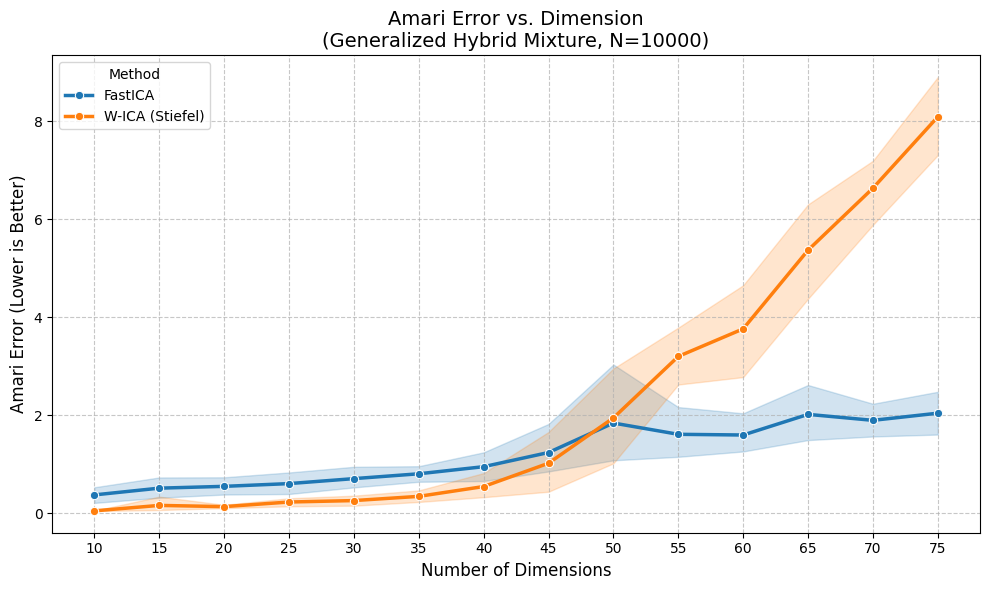

Method,FastICA,W-ICA (Stiefel)
Dimension,,
10,0.3720,0.0464
15,0.5099,0.1579
20,0.5466,0.1328
25,0.6028,0.2270
30,0.7042,0.2563
35,0.8030,0.3422
40,0.9481,0.5428
45,1.2373,1.0185
50,1.8387,1.9434


In [6]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_general, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)
plt.title(f"Amari Error vs. Dimension\n(Generalized Hybrid Mixture, N={N_SAMPLES})", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df_general.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))